# Midpoint prototype: AI4Mars terrain segmentation

This bounded CPU demonstration connects the project's real dataset indexing, split, transform, model, loss, and metric code. It is **prototype validation, not confirmatory hypothesis evidence**. The final H0--H5 analysis requires the complete preregistered three-seed GPU run set.

## Learned big-rock activation map

The next cell safely loads only tensor weights from the trained seed-1414 U-Net checkpoint and computes a label-guided Grad-CAM at the deepest ResNet encoder stage. The scalar target is the mean big-rock logit over expert-labeled big-rock pixels. Warmer colors identify spatial features whose local gradient most increases that target. This is a diagnostic saliency view—not causal proof, calibrated confidence, or confirmatory hypothesis evidence. If the untracked checkpoint or AI4Mars data is unavailable, the cell skips cleanly while the saved notebook output remains inspectable.

{'checkpoint': 'best.ckpt', 'feature_shape': (1, 512, 16, 16), 'expert_big_rock_pixels': 15192, 'saliency_mean': 0.078, 'saliency_p95': 0.568, 'saved': 'paper/figures/unet_bigrock_gradcam.png'}


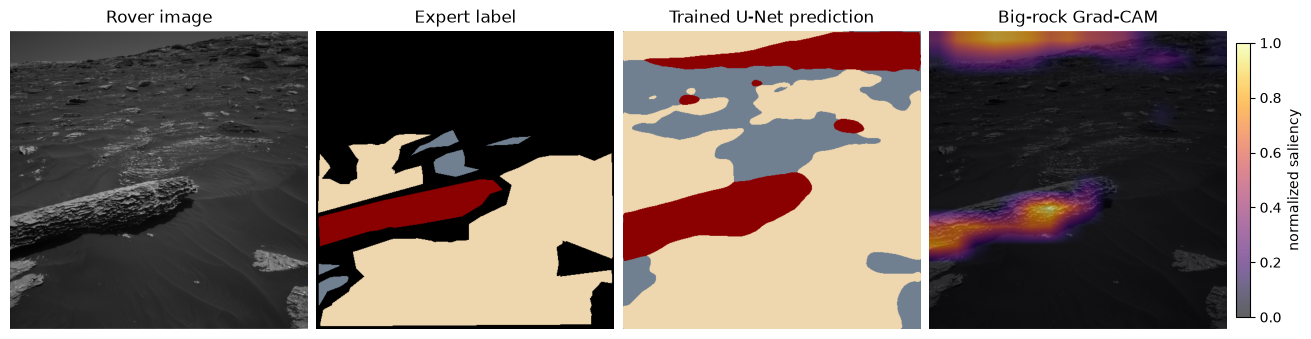

In [1]:
from pathlib import Path
import sys
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

activation_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
ACTIVATION_REPO_ROOT = next((p for p in activation_candidates if (p / 'src' / 'marsseg').is_dir()), None)
if ACTIVATION_REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the repository root or notebooks/ directory.')
sys.path.insert(0, str(ACTIVATION_REPO_ROOT / 'src'))
warnings.filterwarnings('ignore', message='IProgress not found.*')

from marsseg.data.ai4mars import CLASS_COLORS, CLASSES, IGNORE_INDEX, build_index
from marsseg.data.dataset import SegDataset
from marsseg.data.transforms import eval_transform
from marsseg.models.zoo import build_model

ACTIVATION_DATA_ROOT = ACTIVATION_REPO_ROOT / 'data' / 'raw' / 'ai4mars' / 'ai4mars-dataset-merged-0.6'
activation_data_available = (ACTIVATION_DATA_ROOT / 'msl' / 'ncam').is_dir()
activation_index = build_index(ACTIVATION_DATA_ROOT, rover='msl') if activation_data_available else {'test': []}

def activation_colorize(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    rgb[mask == IGNORE_INDEX] = (0, 0, 0)
    return rgb

activation_run = 'unet__pretrained__resnet34__in_rover__seed1414__gpu_full__f8a3ff04__gitc188b320__codebebd8b2d__20260710T232715551236Z'
checkpoint_path = ACTIVATION_REPO_ROOT / 'experiments' / activation_run / 'best.ckpt'
activation_example = 'msl_ncam_nlb_556756308edr_f0651642ncam00285m1'

if activation_data_available and checkpoint_path.exists():
    activation_record = next(r for r in activation_index['test'] if r['name'] == activation_example)
    activation_dataset = SegDataset([activation_record], transform=eval_transform(size=512), rover='msl')
    activation_item = activation_dataset[0]
    activation_image = activation_item['image'].unsqueeze(0).cpu()
    activation_target = activation_item['mask'].unsqueeze(0).cpu()

    trained_unet = build_model('unet', num_classes=len(CLASSES), backbone='resnet34', pretrained=False).cpu().eval()
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    model_weights = {key.removeprefix('model.'): value for key, value in checkpoint['state_dict'].items() if key.startswith('model.')}
    incompatible = trained_unet.load_state_dict(model_weights, strict=True)
    assert not incompatible.missing_keys and not incompatible.unexpected_keys

    features = {}
    gradients = {}
    def capture_deep_features(_module, _inputs, output):
        features['value'] = output
        output.register_hook(lambda grad: gradients.__setitem__('value', grad))

    hook = trained_unet.encoder.layer4.register_forward_hook(capture_deep_features)
    trained_unet.zero_grad(set_to_none=True)
    activation_logits = trained_unet(activation_image)
    big_rock_roi = activation_target == 3
    assert bool(big_rock_roi.any()), 'Selected activation example has no expert big-rock pixels.'
    big_rock_score = activation_logits[:, 3][big_rock_roi].mean()
    big_rock_score.backward()
    hook.remove()

    channel_weights = gradients['value'].mean(dim=(2, 3), keepdim=True)
    gradcam = torch.relu((channel_weights * features['value']).sum(dim=1, keepdim=True))
    gradcam = F.interpolate(gradcam, size=(512, 512), mode='bilinear', align_corners=False)[0, 0]
    gradcam = (gradcam - gradcam.min()) / (gradcam.max() - gradcam.min()).clamp_min(1e-8)
    gradcam = gradcam.detach().cpu().numpy()
    assert float(gradcam.max()) > 0.05, 'Grad-CAM is degenerate for the selected target.'

    raw_activation_image = cv2.imread(activation_record['image'], cv2.IMREAD_GRAYSCALE)
    display_cam = cv2.resize(gradcam, (raw_activation_image.shape[1], raw_activation_image.shape[0]))
    prediction = activation_logits.argmax(1)[0].detach().cpu().numpy()
    expert_mask = activation_target[0].numpy()

    fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), constrained_layout=True)
    axes[0].imshow(raw_activation_image, cmap='gray')
    axes[0].set_title('Rover image')
    axes[1].imshow(activation_colorize(expert_mask))
    axes[1].set_title('Expert label')
    axes[2].imshow(activation_colorize(prediction))
    axes[2].set_title('Trained U-Net prediction')
    axes[3].imshow(raw_activation_image, cmap='gray')
    heat = axes[3].imshow(display_cam, cmap='inferno', alpha=0.62, vmin=0, vmax=1)
    axes[3].set_title('Big-rock Grad-CAM')
    for axis in axes:
        axis.axis('off')
    fig.colorbar(heat, ax=axes[3], fraction=0.046, pad=0.03, label='normalized saliency')
    output_path = ACTIVATION_REPO_ROOT / 'paper' / 'figures' / 'unet_bigrock_gradcam.png'
    fig.savefig(output_path, dpi=200, bbox_inches='tight')
    print({'checkpoint': checkpoint_path.name, 'feature_shape': tuple(features['value'].shape),
           'expert_big_rock_pixels': int(big_rock_roi.sum()),
           'saliency_mean': round(float(gradcam.mean()), 3),
           'saliency_p95': round(float(np.quantile(gradcam, 0.95)), 3),
           'saved': str(output_path.relative_to(ACTIVATION_REPO_ROOT))})
    plt.show()
else:
    print('Activation map skipped: staged AI4Mars data and the untracked trained U-Net checkpoint are required.')

## Preliminary full-run results

The repository currently contains 17 successful full-GPU in-rover mIoU records. Seven configurations have two completed seeds; SegFormer B2 pretrained/scratch and DINOv3-SAT have one. The following values are descriptive only: seed 1416, paired seed/image inference, Holm correction, cross-rover evaluation, and formal H0--H5 decisions remain pending.

In [2]:
import csv
import statistics
from collections import defaultdict
from pathlib import Path

candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next((p for p in candidates if (p / 'src' / 'marsseg').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the repository root or notebooks/ directory.')

prelim_configs = [
    ('tiny_unet', 'none', 'scratch', 'Tiny U-Net scratch'),
    ('unet', 'resnet34', 'pretrained', 'U-Net R34 pretrained'),
    ('unet', 'resnet34', 'scratch', 'U-Net R34 scratch'),
    ('deeplabv3plus', 'resnet50', 'pretrained', 'DeepLabV3+ R50 pretrained'),
    ('deeplabv3plus', 'resnet50', 'scratch', 'DeepLabV3+ R50 scratch'),
    ('segformer', 'mit-b0', 'pretrained', 'SegFormer B0 pretrained'),
    ('segformer', 'mit-b0', 'scratch', 'SegFormer B0 scratch'),
    ('segformer', 'mit-b2', 'pretrained', 'SegFormer B2 pretrained'),
    ('segformer', 'mit-b2', 'scratch', 'SegFormer B2 scratch'),
    ('dinov3_sat', 'vitl16-sat493m', 'finetuned', 'DINOv3-SAT'),
]

results_path = REPO_ROOT / 'experiments' / 'results_store.csv'
if results_path.exists():
    with results_path.open(newline='', encoding='utf-8') as stream:
        result_rows = list(csv.DictReader(stream))
else:
    result_rows = []
    print('Preliminary result table skipped because experiments/results_store.csv is absent.')
grouped = defaultdict(list)
for row in result_rows:
    if row['metric'] == 'miou' and row['stratum'] == 'all' and row['status'] == 'ok' and row['profile'] == 'gpu_full':
        grouped[(row['model'], row['backbone'], row['variant'])].append((int(row['seed']), float(row['value'])))

print(f"{'System':32s} {'Seeds':12s} {'mean mIoU':>10s} {'seed SD':>10s}")
print('-' * 70)
for model, backbone, variant, label in prelim_configs:
    values = sorted(grouped[(model, backbone, variant)])
    if not values:
        continue
    scores = [value for _, value in values]
    seed_text = ','.join(str(seed) for seed, _ in values)
    sd_text = f'{statistics.stdev(scores):.3f}' if len(scores) > 1 else '---'
    print(f'{label:32s} {seed_text:12s} {statistics.mean(scores):10.3f} {sd_text:>10s}')
print('Descriptive midpoint summary only; no hypothesis decisions are made here.')

System                           Seeds         mean mIoU    seed SD
----------------------------------------------------------------------
Tiny U-Net scratch               1414,1415         0.681      0.002
U-Net R34 pretrained             1414,1415         0.821      0.018
U-Net R34 scratch                1414,1415         0.822      0.001
DeepLabV3+ R50 pretrained        1414,1415         0.817      0.022
DeepLabV3+ R50 scratch           1414,1415         0.819      0.012
SegFormer B0 pretrained          1414,1415         0.816      0.016
SegFormer B0 scratch             1414,1415         0.802      0.004
SegFormer B2 pretrained          1414              0.799        ---
SegFormer B2 scratch             1414              0.684        ---
DINOv3-SAT                       1414              0.840        ---
Descriptive midpoint summary only; no hypothesis decisions are made here.


### Scientific figure gallery

Individual seed scores and available-seed means (ranges are not confidence intervals):

![Preliminary mIoU by seed](../paper/figures/preliminary_miou.png)

Representative validation learning curves:

![Validation learning curves](../paper/figures/training_curves.png)

A fixed expert-test scene with substantial big-rock coverage and five seed-1414 predictions:

![Qualitative segmentation comparison](../paper/figures/qualitative_predictions.png)

## Setup and public data

Run the notebook from the repository root or from `notebooks/` after installing the project environment described in `README.md`. AI4Mars data and model weights are deliberately not bundled with the submission.

The merged-0.6 release is public at [Zenodo record 15995036](https://zenodo.org/records/15995036). The expected merged archive is approximately 16.2 GB and has MD5 `daf80a86021253292e6c425f97baa5c6`. From the repository root:

```bash
.venv/bin/python scripts/download_data.py --out data/raw/ai4mars --which merged
.venv/bin/python scripts/check_data.py
```

The expected extraction root is `data/raw/ai4mars/ai4mars-dataset-merged-0.6/`. If it is absent, this notebook prints acquisition instructions and safely skips data-dependent demonstration cells.

In [3]:
from pathlib import Path
import random
import sys
import warnings

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch

candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
REPO_ROOT = next((p for p in candidates if (p / 'src' / 'marsseg').is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError('Run this notebook from the repository root or notebooks/ directory.')
sys.path.insert(0, str(REPO_ROOT / 'src'))

SEED = 1414
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(min(4, max(1, torch.get_num_threads())))
warnings.filterwarnings('ignore', message='IProgress not found.*')

print(f'Repository: {REPO_ROOT.name}')
print(f'Python: {sys.version.split()[0]} | PyTorch: {torch.__version__} | device: CPU')

Repository: AAML-Research-Project
Python: 3.11.15 | PyTorch: 2.4.1+cu121 | device: CPU


In [4]:
from marsseg.data.ai4mars import (
    CLASSES, CLASS_COLORS, DEFAULT_TEST_GOLD_DIR, IGNORE_INDEX, build_index
)
from marsseg.data.dataset import SegDataset, class_pixel_counts, make_splits
from marsseg.data.transforms import eval_transform
from marsseg.eval.metrics import fixed_class_set, macro_miou_from_counts, per_image_counts
from marsseg.models.zoo import build_model
from marsseg.train.loss import CombinedLoss

DATA_ROOT = REPO_ROOT / 'data' / 'raw' / 'ai4mars' / 'ai4mars-dataset-merged-0.6'
DATA_AVAILABLE = (DATA_ROOT / 'msl' / 'ncam').is_dir()

if not DATA_AVAILABLE:
    print('AI4Mars is not staged. Data-dependent cells will be skipped.')
    print('Download: .venv/bin/python scripts/download_data.py --out data/raw/ai4mars --which merged')
    print('Validate: .venv/bin/python scripts/check_data.py')
    index = {'train': [], 'test': []}
    splits = {'train': [], 'val': []}
else:
    index = build_index(DATA_ROOT, rover='msl', camera='ncam', test_gold_dir=DEFAULT_TEST_GOLD_DIR)
    assert len(index['train']) == 16_064, len(index['train'])
    assert len(index['test']) == 322, len(index['test'])
    splits = make_splits(index['train'], val_frac=0.2, seed=SEED)
    assert len(splits['train']) == 12_851
    assert len(splits['val']) == 3_213
    train_names = {r['name'] for r in splits['train']}
    val_names = {r['name'] for r in splits['val']}
    test_names = {r['name'] for r in index['test']}
    assert train_names.isdisjoint(val_names | test_names)
    assert val_names.isdisjoint(test_names)
    print({'msl_train_pool': len(index['train']), 'train': len(splits['train']),
           'validation': len(splits['val']), 'expert_test': len(index['test']),
           'split_overlap': 0})

{'msl_train_pool': 16064, 'train': 12851, 'validation': 3213, 'expert_test': 322, 'split_overlap': 0}


## Deterministic sample inspection

The display uses three fixed validation records. Black label pixels are the ignore value 255 and do not enter the loss or metrics.

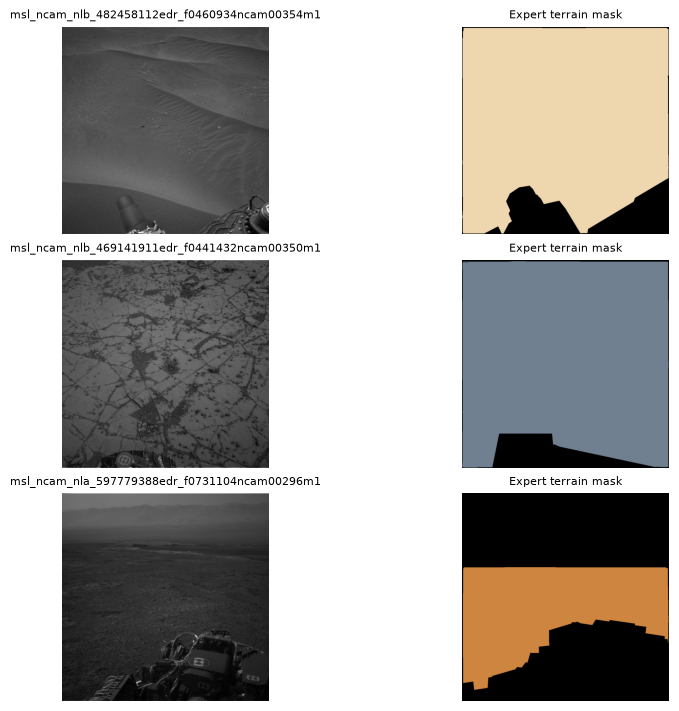

In [5]:
def colorize_mask(mask):
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in CLASS_COLORS.items():
        rgb[mask == class_id] = color
    rgb[mask == IGNORE_INDEX] = (0, 0, 0)
    return rgb

if DATA_AVAILABLE:
    positions = [0, len(splits['val']) // 2, len(splits['val']) - 1]
    sample_records = [splits['val'][i] for i in positions]
    fig, axes = plt.subplots(len(sample_records), 2, figsize=(8, 7), constrained_layout=True)
    for row, rec in enumerate(sample_records):
        image = cv2.imread(rec['image'], cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(rec['label'], cv2.IMREAD_UNCHANGED)
        axes[row, 0].imshow(image, cmap='gray')
        axes[row, 0].set_title(rec['name'], fontsize=8)
        axes[row, 1].imshow(colorize_mask(mask))
        axes[row, 1].set_title('Expert terrain mask', fontsize=8)
        for ax in axes[row]:
            ax.axis('off')
    plt.show()
else:
    sample_records = []
    print('Sample visualization skipped because AI4Mars is not staged.')

In [6]:
if DATA_AVAILABLE:
    counts = class_pixel_counts(sample_records, num_classes=len(CLASSES))
    total = int(counts.sum())
    sample_distribution = {
        name: {'pixels': int(count), 'valid_fraction': round(float(count / total), 4)}
        for name, count in zip(CLASSES, counts)
    }
    print(sample_distribution)
else:
    print('Class-count demonstration skipped because AI4Mars is not staged.')

{'soil': {'pixels': 385047, 'valid_fraction': 0.1711}, 'bedrock': {'pixels': 954625, 'valid_fraction': 0.4242}, 'sand': {'pixels': 910986, 'valid_fraction': 0.4048}, 'big_rock': {'pixels': 0, 'valid_fraction': 0.0}}


## Midpoint status

The prototype verifies the intended code/data interfaces while remaining small enough for CPU execution. Available full-run results, scientific figures, and a trained U-Net big-rock Grad-CAM are included as descriptive midpoint evidence. Confirmatory confidence intervals, Holm-adjusted tests, cross-rover results, and H0--H5 verdicts remain placeholders until canonical runs for training seeds 1414, 1415, and 1416 are complete.